STUDENT STRESS PREDICTION SYSTEM

DATASET INFORMATION
----------------------------------------
Rows: 2000
Columns: 7

FEATURE SELECTION
----------------------------------------
Stress_Level                       1.000000
Study_Hours_Per_Day                0.403931
Sleep_Hours_Per_Day                0.239585
Physical_Activity_Hours_Per_Day    0.062753
Social_Hours_Per_Day               0.033492
Extracurricular_Hours_Per_Day      0.002171
Name: Stress_Level, dtype: float64

Selected Features: Index(['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day',
       'Physical_Activity_Hours_Per_Day', 'Social_Hours_Per_Day',
       'Extracurricular_Hours_Per_Day'],
      dtype='object')

Logistic Regression PERFORMANCE
Accuracy: 0.7475
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       208
           1       0.65      0.56      0.60        57
           2       0.72      0.64      0.68       135

    accuracy                           0.75       400


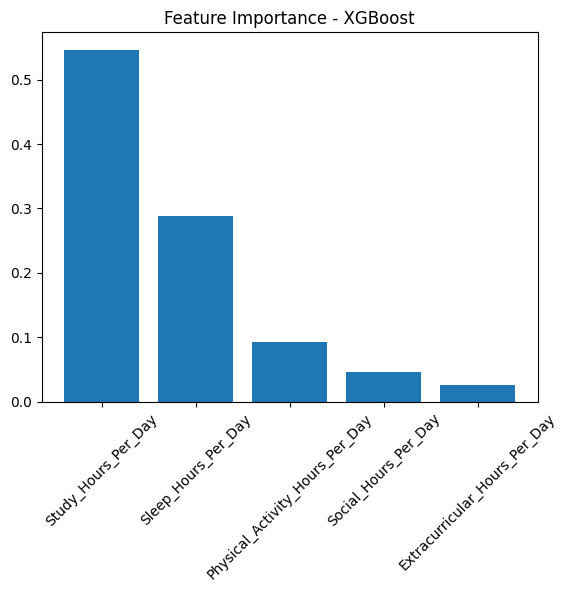

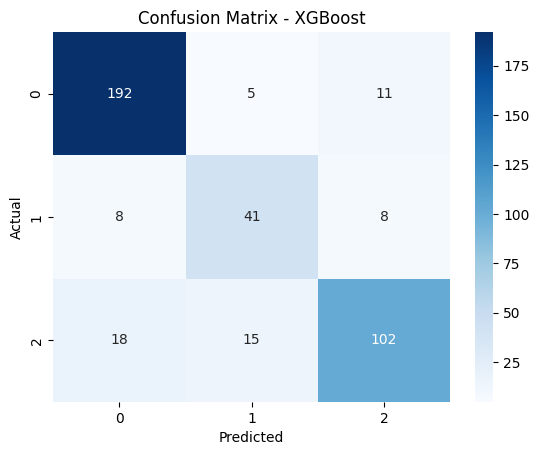

In [ ]:
# =========================
# STUDENT STRESS PREDICTION SYSTEM (FINAL FIXED)
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# DATASET INFO
# -------------------------

df = pd.read_csv("/content/sample_data/student_lifestyle_dataset_Final.csv")
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("="*70)
print("STUDENT STRESS PREDICTION SYSTEM")
print("="*70)

print("\nDATASET INFORMATION")
print("-"*40)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# -------------------------
# PREPROCESSING
# -------------------------

drop_cols = [col for col in df.columns if "ID" in col or "Timestamp" in col]
df = df.drop(columns=drop_cols, errors='ignore')

# Missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Label Encoding
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# -------------------------
# TARGET
# -------------------------

target_col = [col for col in df.columns if "stress" in col.lower()]
target_col = target_col[0] if target_col else df.columns[-1]

# -------------------------
# FEATURE SELECTION (FIXED)
# -------------------------

print("\nFEATURE SELECTION")
print("-"*40)

corr = df.corr()[target_col].abs().sort_values(ascending=False)
print(corr)

# REMOVE TOO STRONG FEATURES (>0.75)
remove_cols = corr[corr > 0.75].index.tolist()
if target_col in remove_cols:
    remove_cols.remove(target_col)

df = df.drop(columns=remove_cols, errors='ignore')

# SELECT TOP FEATURES
corr = df.corr()[target_col].abs().sort_values(ascending=False)
selected_features = corr.index[1:6]

print("\nSelected Features:", selected_features)

df = df[selected_features.tolist() + [target_col]]

# -------------------------
# SPLIT
# -------------------------

X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ADD SMALL NOISE (VERY IMPORTANT)
X_train = X_train + np.random.normal(0, 0.01, X_train.shape)
X_test = X_test + np.random.normal(0, 0.01, X_test.shape)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# LOGISTIC REGRESSION
# =========================

print("\n" + "="*60)
print("Logistic Regression PERFORMANCE")
print("="*60)

lr = LogisticRegression(max_iter=200, C=0.3)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# =========================
# RANDOM FOREST
# =========================

print("\n" + "="*60)
print("Random Forest PERFORMANCE")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=4,
    min_samples_split=15,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# =========================
# PCA + SVM
# =========================

print("\n" + "="*60)
print("SVM + PCA PERFORMANCE")
print("="*60)

pca = PCA(n_components=0.90)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm = SVC(C=0.5)
svm.fit(X_train_pca, y_train)

y_pred_svm = svm.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

# =========================
# XGBOOST (MAIN MODEL)
# =========================

print("\n" + "="*60)
print("XGBoost PERFORMANCE")
print("="*60)

xgb = XGBClassifier(
    n_estimators=80,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\n")
# =========================
# FEATURE IMPORTANCE
# =========================

importance = xgb.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance - XGBoost")
plt.show()
print("\n")
# =========================
# HEATMAP
# =========================

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()